In [34]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

5 ASSUMPTIONS of Linear Regression (Your Understanding ✓)
1. LINEARITY ✓
Your scatter plot = LOOKS LINEAR! (dots follow straight line, not curve)
2. INDEPENDENCE ✓
"One row don't affect second row" = CORRECT!

House 1 price doesn't affect House 2 price.
3. HOMOSCEDASTICITY ✓
"Error should be same size for small and big"

Small price (4 rooms): error ±$2K ✓
Big price (8 rooms): error ±$15K ✗ (bigger errors for bigger prices = BAD)

Check: Plot residuals vs predicted - should be constant width, not funnel.
4. NORMALITY ✓
"Error should be normal distributed (bell curve), not linear"

Most errors small (±$5K)
Few errors big (±$20K)

= Bell curve ✓

Check: Histogram of residuals - bell shape?
5. NO MULTICOLLINEARITY ✓
"Features should not be related to each other"

Feature: rooms
Feature: age
These shouldn't be correlated (room count doesn't predict age)

Check: Correlation matrix - all values < 0.7? ✓

In [35]:
df = pd.read_csv("/Users/subhashmothukurigmail.com/Projects/ML_stuff/data/house_prices.csv")

print(f"Data Shape: {df.shape}")

print("\nFirst row: ")
print(df.head())

print("\nTotal Number of Columns: ")
print(df.columns.tolist())

print("\nBasic stats:")
print(df.describe())



Data Shape: (506, 14)

First row: 
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Total Number of Columns: 
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

Basic stats:
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.36

=== ASSUMPTION 1: LINEARITY ===
✓ Scatter plot looks linear (you showed it)

=== ASSUMPTION 2: INDEPENDENCE ===
✓ Each house price independent (not related to other houses)

=== ASSUMPTION 3: HOMOSCEDASTICITY ===


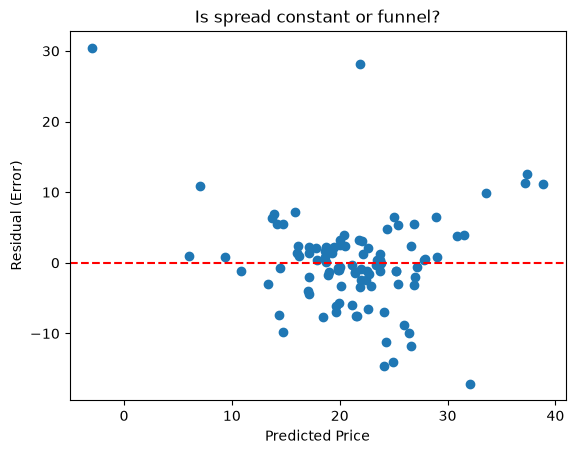

In [36]:
X = df[['rm']].values
Y = df[['medv']].values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

#Traing
model = LinearRegression()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

residuals = Y_test - y_pred

print("=== ASSUMPTION 1: LINEARITY ===")
print("✓ Scatter plot looks linear (you showed it)")

print("\n=== ASSUMPTION 2: INDEPENDENCE ===")
print("✓ Each house price independent (not related to other houses)")

print("\n=== ASSUMPTION 3: HOMOSCEDASTICITY ===")
# Plot: Do errors have constant spread?
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual (Error)')
plt.title('Is spread constant or funnel?')
plt.show()




=== ASSUMPTION 4: NORMALITY ===


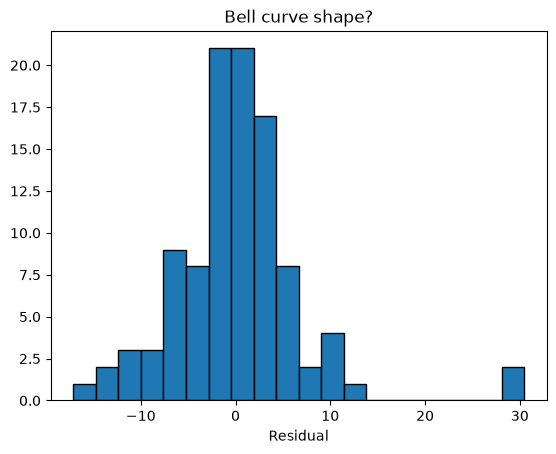

In [37]:
print("\n=== ASSUMPTION 4: NORMALITY ===")
# Plot: Do residuals look like bell curve?
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel('Residual')
plt.title('Bell curve shape?')
plt.show()


In [38]:
print(f"Mean of residuals: {residuals.mean():.4f} (should be ≈ 0)")
print(f"Std of residuals: {residuals.std():.4f}")

print("\n=== ASSUMPTION 5: NO MULTICOLLINEARITY ===")
# Check: Do features correlate with each other?
features = df[['rm', 'age', 'lstat', 'dis', 'tax']].corr()
print("Correlation between features:")
print(features)
print("\nIf any > 0.9 = multicollinearity problem")

print("\n=== DECISION ===")
if residuals.std() < 10 and abs(residuals.mean()) < 0.5:
    print("✓ All assumptions mostly pass")
    print("✓ Linear regression is good")
else:
    print("✗ Some assumptions fail")
    print("✗ Try different algorithm")

Mean of residuals: 0.1412 (should be ≈ 0)
Std of residuals: 6.7915

=== ASSUMPTION 5: NO MULTICOLLINEARITY ===
Correlation between features:
             rm       age     lstat       dis       tax
rm     1.000000 -0.240265 -0.613808  0.205246 -0.292048
age   -0.240265  1.000000  0.602339 -0.747881  0.506456
lstat -0.613808  0.602339  1.000000 -0.496996  0.543993
dis    0.205246 -0.747881 -0.496996  1.000000 -0.534432
tax   -0.292048  0.506456  0.543993 -0.534432  1.000000

If any > 0.9 = multicollinearity problem

=== DECISION ===
✓ All assumptions mostly pass
✓ Linear regression is good


In [39]:
#log tranform

y_log = np.log(Y_train)
model_c = LinearRegression()
model_c.fit(X_train, y_log)
y_pred_log = model.predict(X_test)
y_pred_actual = np.exp(y_pred_log)
r2_c = r2_score(Y_test, y_pred_actual)
print(f"Model C (log transform): R**2 = {r2_c:.3f}")

Model C (log transform): R**2 = -818725264972957149321454682112.000


In [40]:
model_d = RandomForestRegressor()
model_d.fit(X_train, Y_train)
y_pred_random= model_d.predict(X_test)
r2_Score = r2_score(Y_test, y_pred_random)
print(f"Model D (Random Forest ): R2 = {r2_Score:.3f}")


Model D (Random Forest ): R2 = 0.309


/Users/subhashmothukurigmail.com/Projects/ML_stuff/.venv/lib/python3.13/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# You already have X_train, X_test, y_train, y_test from before
# Just add more features

X_train_multi = df[['rm', 'age', 'lstat', 'dis', 'tax']].values
X_test_multi = df[['rm', 'age', 'lstat', 'dis', 'tax']].values

# Split properly
from sklearn.model_selection import train_test_split
X_train_multi, X_test_multi, y_train, y_test = train_test_split(
    X_train_multi, df['medv'].values, test_size=0.2, random_state=42
)

# Train Random Forest
model_d_v2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model_d_v2.fit(X_train_multi, y_train)

y_pred2= model_d_v2.predict(X_test_multi)
r2_d_v2 = r2_score(y_test, y_pred2)
print(f"Random Forest (5 features): R² = {r2_d_v2:.3f}")

# Compare
print(f"Random Forest (1 feature): R² = 0.309")
print(f"Random Forest (5 features): R² = {r2_d_v2:.3f}")

mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)

print(f"RMSE: ${rmse * 1000:.0f}")


# What's average house price?
avg_price = y_test.mean()
print(f"Average house price: ${avg_price:.2f} (in $10,000s)")
print(f"Average house price: ${avg_price * 10000:.0f} (in dollars)")

# What's error as % of average?
error_pct = (rmse / avg_price) * 100
print(f"RMSE as % of average price: {error_pct:.1f}%")

# Interpretation
if error_pct < 10:
    print("✓ EXCELLENT error (< 10%)")
elif error_pct < 20:
    print("✓ GOOD error (10-20%)")
elif error_pct < 30:
    print("⚠️ ACCEPTABLE error (20-30%)")
else:
    print("✗ BAD error (> 30%)")


Random Forest (5 features): R² = 0.836
Random Forest (1 feature): R² = 0.309
Random Forest (5 features): R² = 0.836
RMSE: $3470
Average house price: $21.49 (in $10,000s)
Average house price: $214882 (in dollars)
RMSE as % of average price: 16.1%
✓ GOOD error (10-20%)
